# 03. 작물 배치 최적화 + 기후 시나리오 연결 (Stage 2)

1단계에서 학습한 모델로 기후 시나리오별(`baseline` vs `drought_heat`) 수확량을 예측하고, 토지·물 제약 하에서 전체 생산량을 최대화하는 작물 배치를 LP로 구한다 (`src/optimizer.py`, `src/scenarios.py`).

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd()
_root = _root.parent if _root.name == 'notebooks' else _root
sys.path.insert(0, str(_root))
import pandas as pd
from src.data_loader import load_or_build_processed
from src.model import load_best_models
from src.optimizer import optimize_allocation
from src import visualize as viz

panel, constraints = load_or_build_processed()
models = load_best_models()

## 왜 제약이 필요한가: 목적함수만 '총생산 최대화'일 때

물·최소 생산량 제약 없이 풀면 가장 수확량 높은 작물(옥수수) 한 가지로 전부 쏠리는 시시한 해가 나온다.

In [2]:
from src.scenarios import build_scenarios, predict_scenario_yields
from src.generate_synthetic_data import CROP_PARAMS

scenario_climate = build_scenarios(panel)
baseline_yields = predict_scenario_yields(scenario_climate['baseline'], models)
water_use = {c: p['water_use_acre_in'] for c, p in CROP_PARAMS.items()}

degenerate = optimize_allocation(baseline_yields, constraints, water_use=water_use)
degenerate.allocation.groupby('crop')['acres'].sum()

crop
corn       32539650.57
soybean           0.00
wheat             0.00
Name: acres, dtype: float64

결과를 보면 옥수수에 모든 면적이 쏠린다 — 제약이 더 필요하다는 뜻이다. `src/scenarios.py`는 **국가 단위 관개용수 예산의 일정 비율을 각 작물에 최소/최대로 배정**하는 정책 제약을 추가해 의미 있는 트레이드오프를 만든다.

## 기후 시나리오별 최적화 실행

In [3]:
from src.scenarios import run_scenario_analysis

out = run_scenario_analysis(panel, constraints, models)
out['summary']

,scenario,total_production_bu
0,baseline_optimal,3.167485e+09
1,drought_no_adaptation,2.145627e+09
2,drought_adapted,2.166563e+09


In [4]:
print(f"Production saved by reallocation under drought/heat: "
      f"{out['production_saved_bu']:,.0f} bu ({out['production_saved_pct']:.2f}%)")

Production saved by reallocation under drought/heat: 20,936,360 bu (0.98%)


## 시각화: 시나리오별 총생산

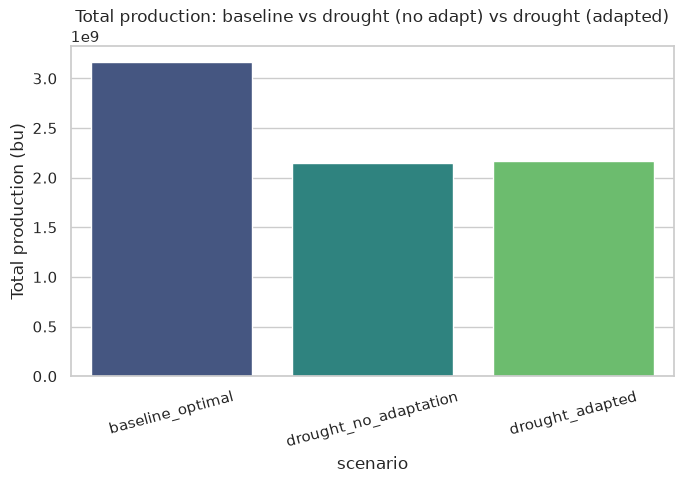

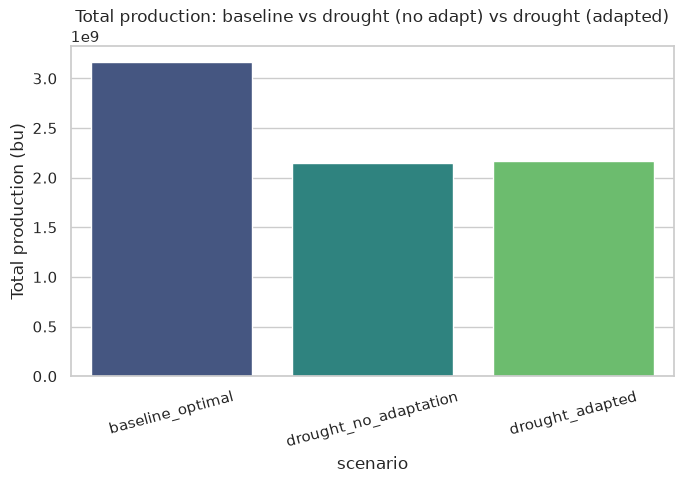

In [5]:
fig = viz.plot_scenario_comparison(out['summary'])
fig

## 시각화: 기준 vs 가뭄-적응 배치 (주 x 작물)

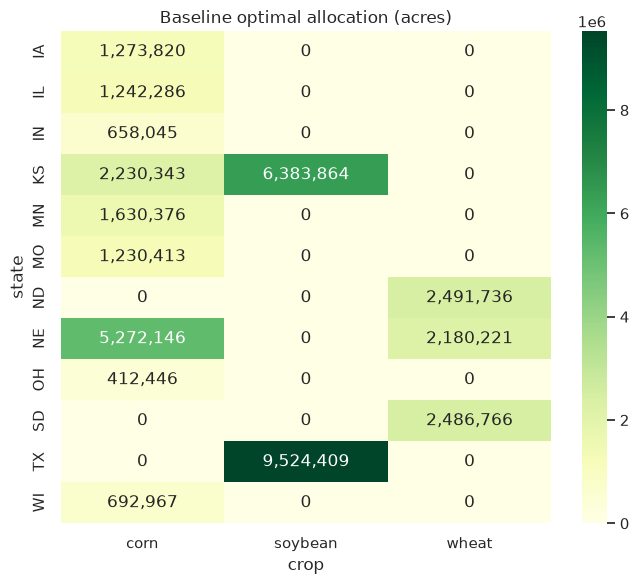

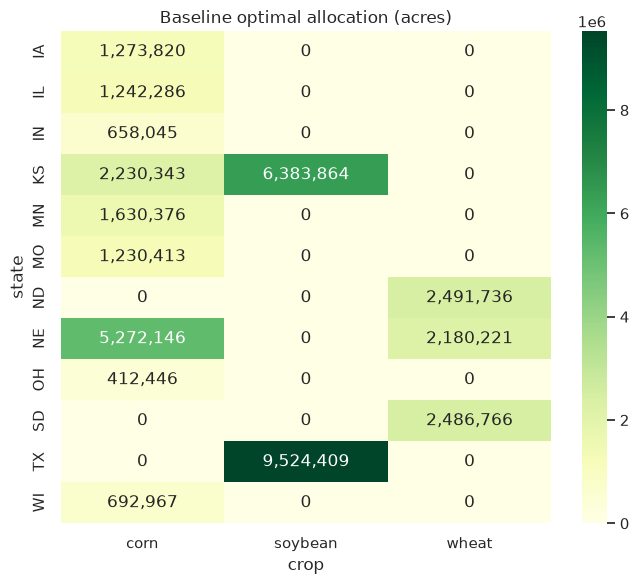

In [6]:
fig = viz.plot_allocation_heatmap(out['baseline_result'].allocation, 'Baseline optimal allocation (acres)', 'allocation_baseline.png')
fig

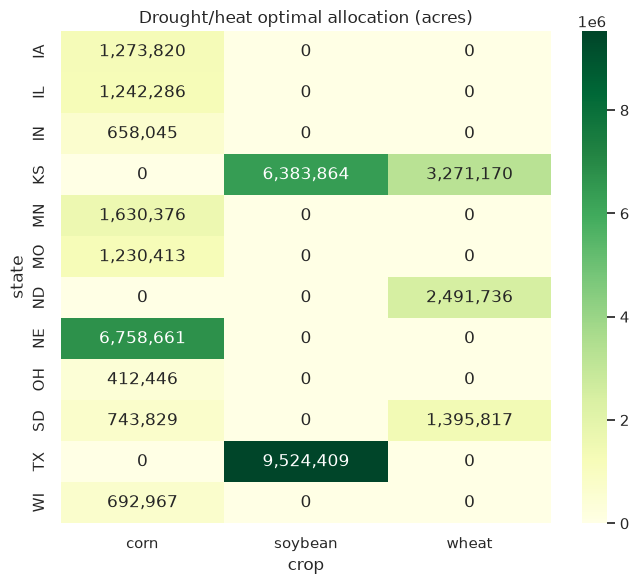

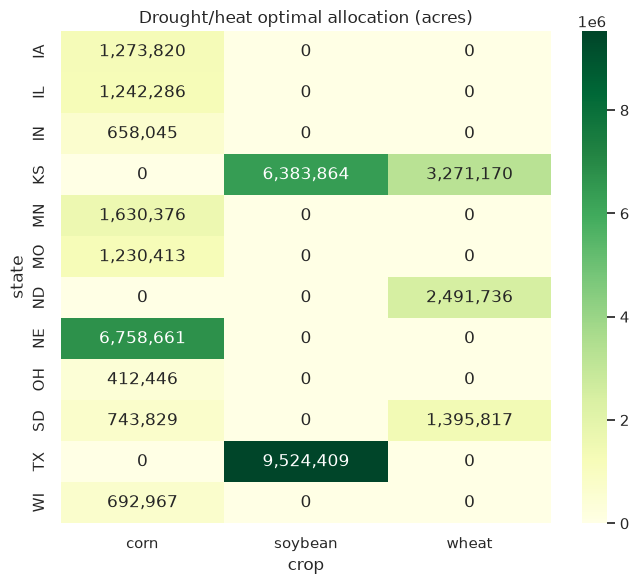

In [7]:
fig = viz.plot_allocation_heatmap(out['adapted_result'].allocation, 'Drought/heat optimal allocation (acres)', 'allocation_drought_adapted.png')
fig

## 가뭄 시 주별 재배치 패턴

작물별 국가 총 면적은 정책 제약(최소/최대 비중)에 의해 거의 동일하게 유지되지만, **어느 주에서 무엇을 심을지**는 기후 충격에 따라 달라진다 — 이것이 '적응(adaptation)'의 본질이다.

In [8]:
base = out['baseline_result'].allocation
adapt = out['adapted_result'].allocation
merged = base.merge(adapt, on=['state', 'crop'], suffixes=('_baseline', '_drought_adapted'))
merged['acre_shift'] = merged['acres_drought_adapted'] - merged['acres_baseline']
merged.loc[merged['acre_shift'].abs() > 1000, ['state', 'crop', 'acres_baseline', 'acres_drought_adapted', 'acre_shift']]\
    .sort_values('acre_shift')

,state,crop,acres_baseline,acres_drought_adapted,acre_shift
9,KS,corn,2230343.2,0.00,-2230343.20
23,NE,wheat,2180220.6,0.00,-2180220.60
29,SD,wheat,2486766.4,1395817.00,-1090949.40
27,SD,corn,0.0,743829.14,743829.14
21,NE,corn,5272146.5,6758660.60,1486514.10
11,KS,wheat,0.0,3271170.00,3271170.00


## 결론

- 가뭄/고온 시나리오에서는 기준 대비 총생산이 크게 감소한다 (수확량 자체가 떨어지기 때문에 불가피).
- 같은 작물 구성(정책상 최소/최대 비중)을 유지한 채로도, **어느 주가 어떤 작물을 맡을지 재배치하는 것만으로** 적응하지 않았을 때보다 생산을 추가로 지켜낼 수 있다.
- 다만 그 효과는 제한적이다 — 이는 순수한 공간 재배치만으로는 기후 피해의 일부만 상쇄할 수 있고, 관개 인프라 투자나 내건성 품종 개발 같은 다른 적응 전략이 함께 필요함을 시사한다.